ipywidgets not installed. Please install it for interactive visualization.


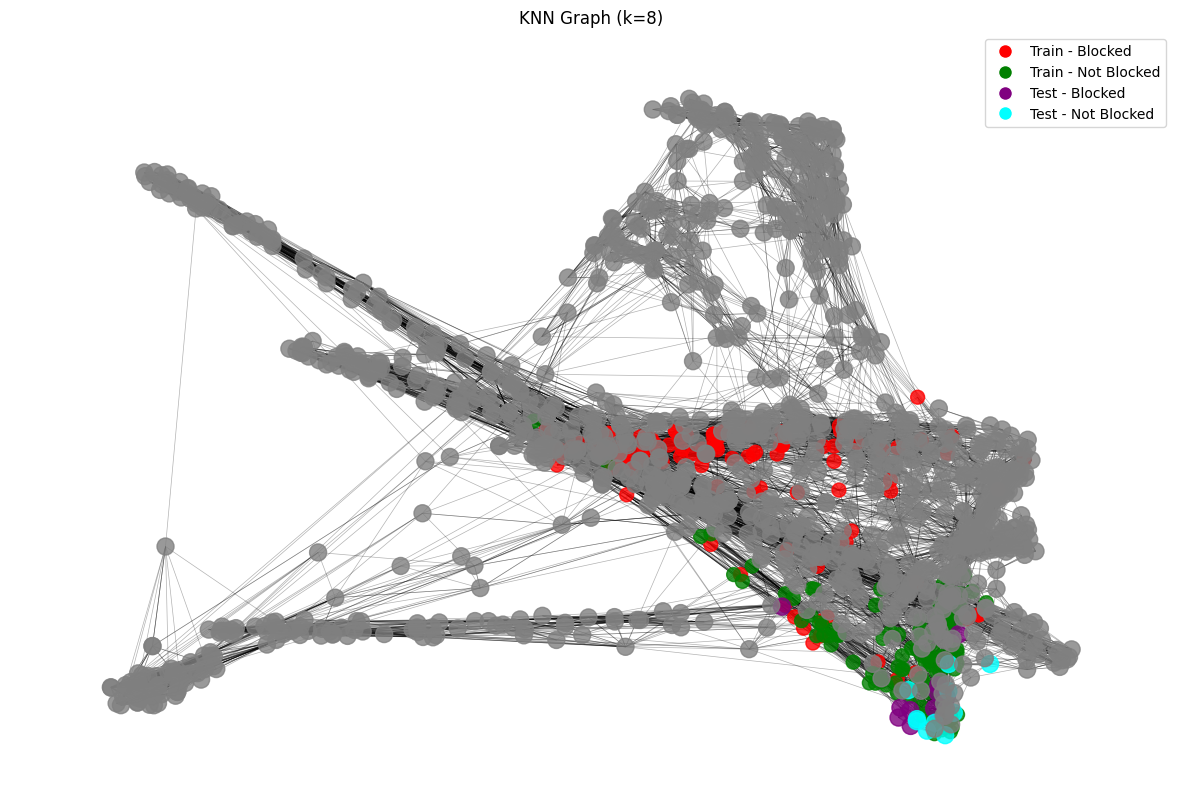

Graph info: 1360 nodes, 10876 edges


In [2]:
def visualize_knn_graph(rankings, k=16, figsize=(15, 10), title=None, node_colors=None, 
                        show_labels=False, layout='spring', save_path=None):
    """
    Visualize a KNN graph based on rankings.
    
    Parameters:
    -----------
    rankings : numpy.ndarray
        The ranking indices from BallTree or similar
    k : int
        Number of neighbors to visualize for each node
    figsize : tuple
        Size of the figure
    title : str
        Title of the plot
    node_colors : list
        Colors for nodes (default colors are based on classification)
    show_labels : bool
        Whether to show node labels
    layout : str
        Graph layout algorithm ('spring', 'kamada_kawai', 'circular', etc.)
    save_path : str
        Path to save the figure
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    from matplotlib.colors import to_rgba
    
    # Create a graph
    G = nx.DiGraph()
    
    # Add nodes to the graph
    for i in range(len(rankings)):
        G.add_node(i)
    
    # Add edges based on k-nearest neighbors
    for i in range(len(rankings)):
        # Skip the first neighbor as it's the point itself
        for j in range(1, min(k+1, len(rankings[i]))):
            if i != rankings[i][j]: 
                G.add_edge(i, rankings[i][j])
    
    # Setup node colors if not provided
    if node_colors is None:
        colors = []
        for i in range(len(rankings)):
            if 0 <= i < 100:  # Yes train
                colors.append('red')
            elif 100 <= i < 200:  # No train
                colors.append('green')
            elif 200 <= i < 210:  # Yes test
                colors.append('purple')
            elif 210 <= i < 220:  # No test
                colors.append('cyan')
            else:  # Handle any other indices
                colors.append('gray')
    else:
        colors = node_colors
    
    # Layout options
    layout_funcs = {
        'spring': nx.spring_layout,
        'kamada_kawai': nx.kamada_kawai_layout,
        'circular': nx.circular_layout,
        'random': nx.random_layout,
        'shell': nx.shell_layout
    }
    
    # Create layout
    layout_func = layout_funcs.get(layout, nx.spring_layout)
    pos = layout_func(G)
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Draw nodes with colors
    node_sizes = [100 if i < 200 else 150 for i in range(len(rankings))]  # Larger nodes for test data
    
    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, arrows=False)
    
    if show_labels:
        nx.draw_networkx_labels(G, pos, font_size=8)
    
    # Add legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Train - Blocked'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label='Train - Not Blocked'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='purple', markersize=10, label='Test - Blocked'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan', markersize=10, label='Test - Not Blocked')
    ]
    plt.legend(handles=legend_elements, loc='best')
    
    # Set title
    if title:
        plt.title(title)
    else:
        plt.title(f'KNN Graph (k={k})')
    
    plt.axis('off')
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print some graph statistics
    print(f"Graph info: {len(G.nodes)} nodes, {len(G.edges)} edges")
    return G

# Interactive function to visualize with different k values
def interactive_knn_visualization(rankings):
    """
    Provides an interactive visualization with sliders for k values
    """
    try:
        import ipywidgets as widgets
        from IPython.display import display
        
        # Create widgets
        k_slider = widgets.IntSlider(min=1, max=30, step=1, value=5, description='k:')
        layout_dropdown = widgets.Dropdown(
            options=['spring', 'kamada_kawai', 'circular', 'shell', 'random'],
            value='spring',
            description='Layout:'
        )
        show_labels_checkbox = widgets.Checkbox(value=False, description='Show Labels')
        
        # Function to update visualization
        def update_viz(k, layout, show_labels):
            visualize_knn_graph(rankings, k=k, layout=layout, show_labels=show_labels,
                              title=f'KNN Graph (k={k}, layout={layout})')
        
        # Create interactive widget
        interactive_plot = widgets.interactive(update_viz, 
                                              k=k_slider, 
                                              layout=layout_dropdown, 
                                              show_labels=show_labels_checkbox)
        
        # Display the interactive plot
        display(interactive_plot)
        
    except ImportError:
        print("ipywidgets not installed. Please install it for interactive visualization.")
        # Fall back to static visualization
        visualize_knn_graph(rankings, k=8)

# Example usage
# Load the rankings from JSON
import json
import os


try:
    with open("./Runs/alexnet_output.json", "r") as f:
        rankings = json.load(f)
    
    # Convert to numpy array if needed
    import numpy as np
    rankings = np.array(rankings)
    
    # Call the visualization function
    interactive_knn_visualization(rankings)
    
except FileNotFoundError:
    print("Rankings file not found. Please ensure bert_output.json exists in the Runs directory.")

{0: array([ 0.34346476, -0.72422981]), 1: array([ 0.38672057, -0.71675992]), 2: array([ 0.35697642, -0.71391457]), 3: array([ 0.3493132 , -0.74675727]), 4: array([ 0.34308603, -0.74271196]), 5: array([ 0.34739286, -0.73016113]), 6: array([ 0.36627695, -0.74311602]), 7: array([ 0.3511382 , -0.72513443]), 8: array([ 0.35567325, -0.74245155]), 9: array([ 0.37955824, -0.70323372]), 10: array([ 0.37052599, -0.70614225]), 11: array([ 0.36600164, -0.70547765]), 12: array([ 0.36078197, -0.70232409]), 13: array([ 0.37071481, -0.73653001]), 14: array([ 0.3639636 , -0.72645581]), 15: array([ 0.36246035, -0.71933097]), 16: array([ 0.36357656, -0.71274072]), 17: array([ 0.33459035, -0.7320053 ]), 18: array([ 0.3591575 , -0.74663252]), 19: array([ 0.37026608, -0.70791316]), 20: array([ 0.36244178, -0.73798984]), 21: array([ 0.37280357, -0.73880267]), 22: array([ 0.35641229, -0.74264491]), 23: array([ 0.34374538, -0.71880144]), 24: array([ 0.36563596, -0.73963279]), 25: array([ 0.38262975, -0.7148427

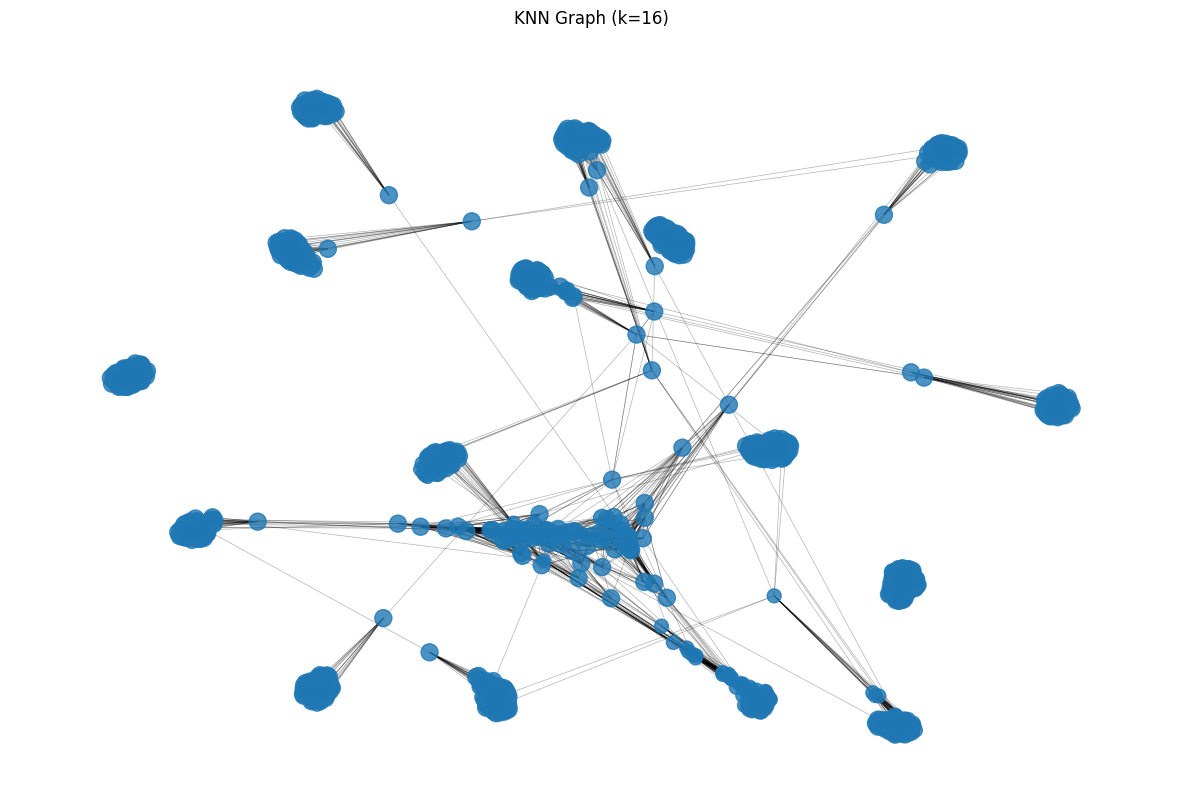

Graph info: 1360 nodes, 21756 edges


In [6]:
def visualize_knn_graph(rankings, k=16, figsize=(15, 10), title=None, 
                        show_labels=False, save_path=None):
    """
    Visualize a KNN graph based on rankings using spring layout.
    
    Parameters:
    -----------
    rankings : numpy.ndarray
        The ranking indices from BallTree or similar
    k : int
        Number of neighbors to visualize for each node
    figsize : tuple
        Size of the figure
    title : str
        Title of the plot
    node_colors : list
        Colors for nodes (default colors are based on classification)
    show_labels : bool
        Whether to show node labels
    save_path : str
        Path to save the figure
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    
    # Create a graph
    G = nx.DiGraph()
    
    # Add nodes to the graph
    for i in range(len(rankings)):
        G.add_node(i)
    
    # Add edges based on k-nearest neighbors
    for i in range(len(rankings)):
        # Skip the first neighbor as it's the point itself
        for j in range(1, min(k+1, len(rankings[i]))):
            if i != rankings[i][j]: 
                G.add_edge(i, rankings[i][j])
    
    # Create spring layout
    pos = nx.spring_layout(G)
    print(pos)
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Draw nodes with colors
    node_sizes = [100 if i < 200 else 150 for i in range(len(rankings))]  # Larger nodes for test data
    
    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, arrows=False)
    
    if show_labels:
        nx.draw_networkx_labels(G, pos, font_size=8)
    
    
    # Set title
    if title:
        plt.title(title)
    else:
        plt.title(f'KNN Graph (k={k})')
    
    plt.axis('off')
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print some graph statistics
    print(f"Graph info: {len(G.nodes)} nodes, {len(G.edges)} edges")
    return G

# Example usage
import json
import os
import numpy as np

try:
    with open("./Runs/dinov2_vits14_output.json", "r") as f:
        rankings = json.load(f)
    
    # Convert to numpy array
    rankings = np.array(rankings)
    
    # Call the visualization function with default parameters
    visualize_knn_graph(rankings, k=16)
    
except FileNotFoundError:
    print("Rankings file not found. Please ensure alexnet_output.json exists in the Runs directory.")

{0: array([-0.67943656, -0.57886714]), 1: array([-0.67703938, -0.59334886]), 2: array([-0.72586703, -0.63872683]), 3: array([-0.73982304, -0.61479783]), 4: array([-0.66491753, -0.58507383]), 5: array([-0.72945225, -0.61074054]), 6: array([-0.6756109 , -0.60707611]), 7: array([-0.71533209, -0.63777441]), 8: array([-0.70576102, -0.64289027]), 9: array([-0.70352918, -0.66574824]), 10: array([-0.68854421, -0.66037941]), 11: array([-0.72814327, -0.66175359]), 12: array([-0.68827158, -0.59226882]), 13: array([-0.70195299, -0.63337445]), 14: array([-0.68033761, -0.65929151]), 15: array([-0.7032122 , -0.67603928]), 16: array([-0.72684139, -0.61793166]), 17: array([-0.59984386, -0.54384571]), 18: array([-0.7138195 , -0.65480548]), 19: array([-0.68109745, -0.62278789]), 20: array([-0.72399348, -0.64979792]), 21: array([-0.7465831, -0.6297605]), 22: array([-0.72396314, -0.62605333]), 23: array([-0.71464449, -0.61802995]), 24: array([-0.71524888, -0.67375183]), 25: array([-0.6039744 , -0.54580897]

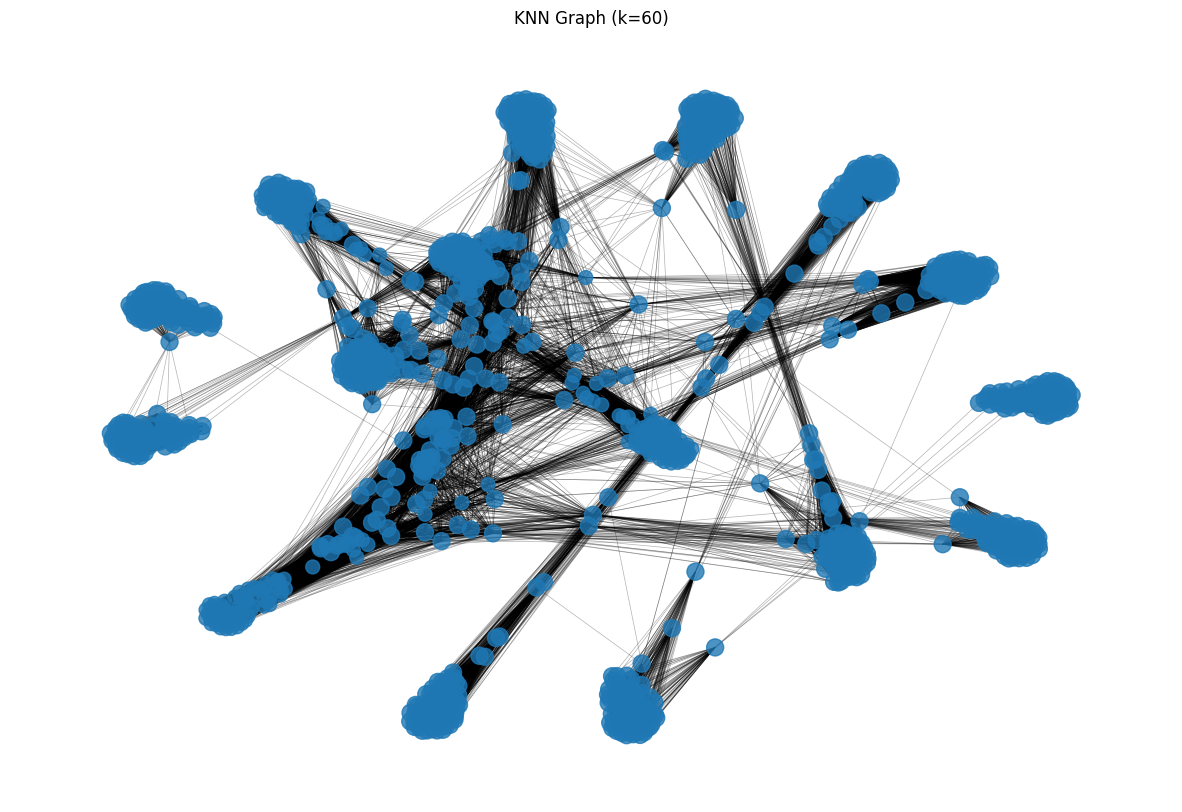

Graph info: 1360 nodes, 81596 edges


In [1]:
def visualize_knn_graph(rankings, k=16, figsize=(15, 10), title=None, 
                        show_labels=False, save_path=None):
    """
    Visualize a KNN graph based on rankings using spring layout.
    
    Parameters:
    -----------
    rankings : numpy.ndarray
        The ranking indices from BallTree or similar
    k : int
        Number of neighbors to visualize for each node
    figsize : tuple
        Size of the figure
    title : str
        Title of the plot
    node_colors : list
        Colors for nodes (default colors are based on classification)
    show_labels : bool
        Whether to show node labels
    save_path : str
        Path to save the figure
    """
    import networkx as nx
    import matplotlib.pyplot as plt
    
    # Create a graph
    G = nx.DiGraph()
    
    # Add nodes to the graph
    for i in range(len(rankings)):
        G.add_node(i)
    
    # Add edges based on k-nearest neighbors
    for i in range(len(rankings)):
        # Skip the first neighbor as it's the point itself
        for j in range(1, min(k+1, len(rankings[i]))):
            if i != rankings[i][j]: 
                G.add_edge(i, rankings[i][j])
    
    # Create spring layout with increased spacing between nodes
    pos = nx.spring_layout(G, k=0.3, iterations=100, seed=42)
    print(pos)
    
    # Create figure
    plt.figure(figsize=figsize)
    
    # Draw nodes with colors
    node_sizes = [100 if i < 200 else 150 for i in range(len(rankings))]  # Larger nodes for test data
    
    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.8)
    nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3, arrows=False)
    
    if show_labels:
        nx.draw_networkx_labels(G, pos, font_size=8)
    
    
    # Set title
    if title:
        plt.title(title)
    else:
        plt.title(f'KNN Graph (k={k})')
    
    plt.axis('off')
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Print some graph statistics
    print(f"Graph info: {len(G.nodes)} nodes, {len(G.edges)} edges")
    return G, pos

# Example usage
import json
import os
import numpy as np

try:
    with open("./Runs/dinov2_vits14_output.json", "r") as f:
        rankings = json.load(f)
    
    # Convert to numpy array
    rankings = np.array(rankings)
    
    # Call the visualization function with default parameters
    G, pos = visualize_knn_graph(rankings, k=60)

    
except FileNotFoundError:
    print("Rankings file not found. Please ensure alexnet_output.json exists in the Runs directory.")

In [11]:


def export_graph_positions(G, pos, output_path="./Runs/graph_positions.json"):
    """
    Export the graph node positions to a JSON file.
    
    Parameters:
    -----------
    G : networkx.Graph
        The graph whose positions will be exported
    pos : dict
        Dictionary of node positions {node_id: (x, y)}
    output_path : str
        Path where the JSON file will be saved
    
    Returns:
    --------
    str
        Path to the saved JSON file
    """
    # Create a serializable dictionary of positions
    # Convert numpy arrays to lists for JSON serialization
    export_data = {
        "nodes": {},
        "graph_info": {
            "num_nodes": len(G.nodes),
            "num_edges": len(G.edges)
        }
    }
    
    # Add node positions and any attributes
    for node_id in G.nodes():
        node_pos = pos[node_id]
        # Convert numpy arrays or tuples to lists for JSON serialization
        position = [float(node_pos[0]), float(node_pos[1])]
        
        # Include node attributes if available
        node_attrs = dict(G.nodes[node_id])
        export_data["nodes"][str(node_id)] = {
            "position": position,
            "attributes": node_attrs
        }
    
    # Ensure the output directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Save to JSON file
    with open(output_path, 'w') as f:
        json.dump(export_data, f, indent=2)
    
    print(f"Graph positions exported to {output_path}")
    return output_path


# Export the positions
output_path = "Runs/graph_positions.json"
export_graph_positions(G, pos, output_path)
# 

Graph positions exported to Runs/graph_positions.json


'Runs/graph_positions.json'